# colab

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

ModuleNotFoundError: No module named 'torchvision'

In [60]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

In [61]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [ ]:
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [63]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [64]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


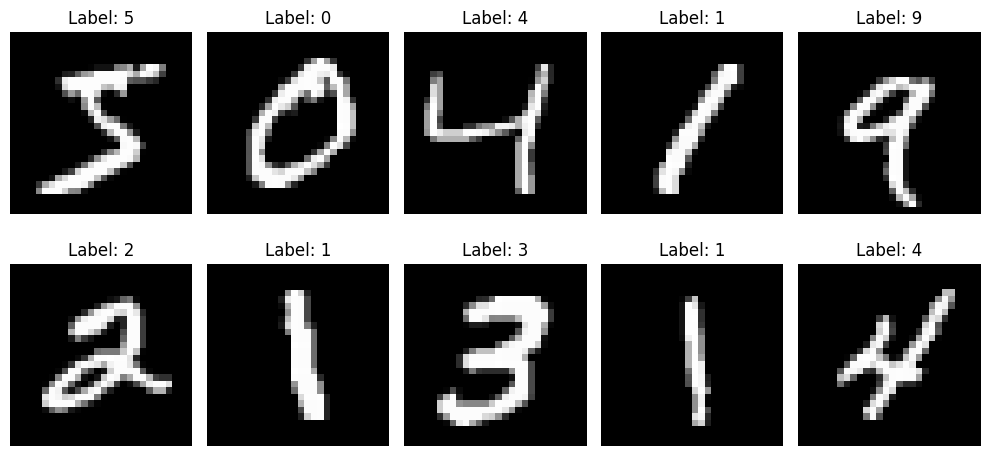

In [65]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    image, label = train_dataset[i]

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [66]:
class MNIST_CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.fc2(x)

        return x

In [67]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


Using device: cuda


In [68]:
model = MNIST_CNN().to(device)

print(model)


MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [69]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)

Total parameters: 421642


In [70]:
criterion = nn.CrossEntropyLoss()

In [71]:
optimizer = optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9
)

#Adam
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [72]:
epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.1291 Accuracy: 96.07%
Epoch [2/5] Loss: 0.0401 Accuracy: 98.78%
Epoch [3/5] Loss: 0.0270 Accuracy: 99.15%
Epoch [4/5] Loss: 0.0190 Accuracy: 99.40%
Epoch [5/5] Loss: 0.0165 Accuracy: 99.43%


In [73]:
model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = 100 * correct / total

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 99.03%


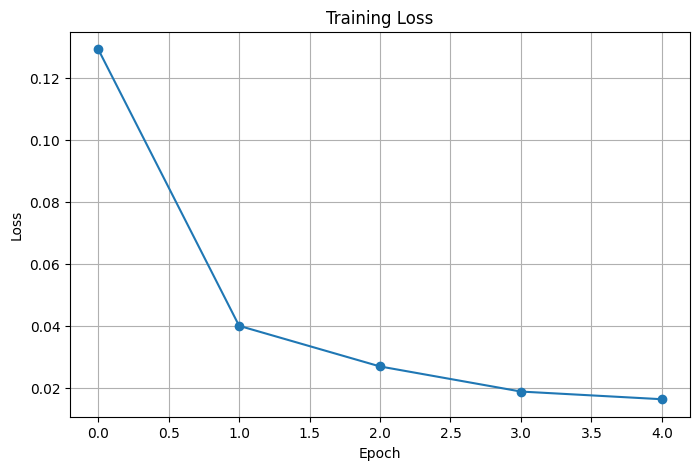

In [74]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid()
plt.show()

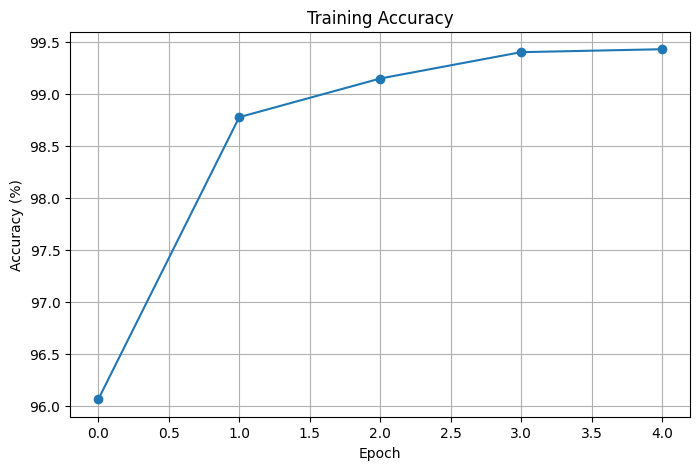

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.grid()
plt.show()

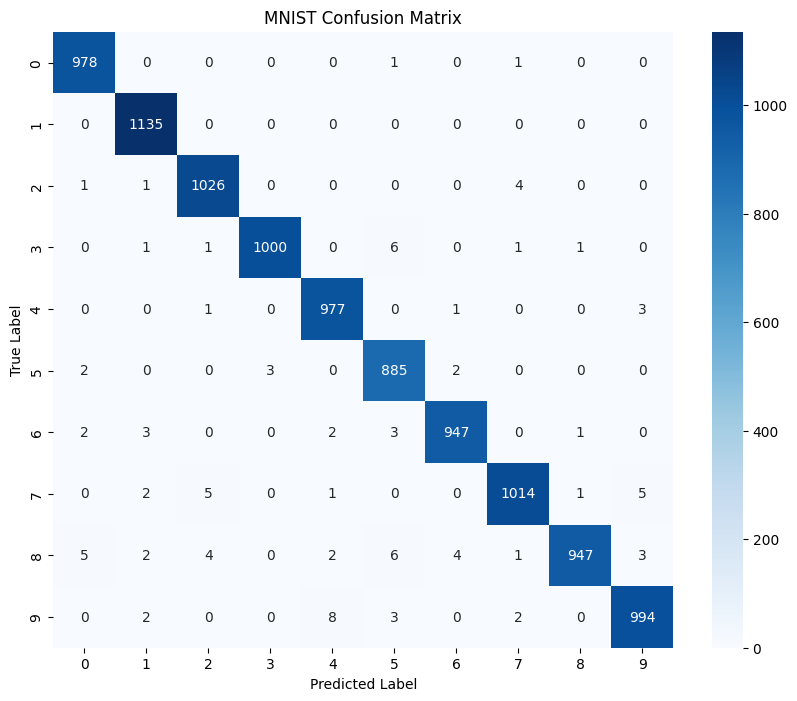

In [76]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")

plt.show()

In [80]:
wrong_indices = np.where(
    np.array(all_predictions)
    != np.array(all_labels)
)[0]

print(
    "Number of wrong predictions:",
    len(wrong_indices)
)

Number of wrong predictions: 97


# **Eval**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model, test_loader, device):
    
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        average="weighted"
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="weighted"
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted"
    )

    print("===== MODEL EVALUATION =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions
        )
    )

    return all_labels, all_predictions

In [87]:
all_labels, all_predictions = evaluate_model(
    model,
    test_loader,
    device
)

===== MODEL EVALUATION =====
Accuracy : 0.9903
Precision: 0.9903
Recall   : 0.9903
F1 Score : 0.9903

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.97      0.98       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

